# Central Limit Theorem and Poisson Distribution
This notebook demonstrates the practical application of the **Central Limit Theorem (CLT)** and the **Poisson Distribution**. It leverages custom utility functions to solve real-world statistical problems and visualizes the underlying mathematical behaviors.

## 1. Setup and Imports
We import standard data science libraries along with our custom statistical functions.

In [26]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

# Importing the pre-defined functions from our library
from numstats.clt_poisson import (
    poisson_pmf,
    poisson_extended,
    clt_interval_probability,
    calculate_sample_size
)

np.random.seed(42)  # Set seed for reproducibility

## 2. Visual Proof of the Central Limit Theorem (CLT)
The CLT states that given a sufficiently large sample size ($n$), the distribution of the sum of independent and identically distributed variables will approximate a normal distribution, regardless of the variables' original shape.

Below, we simulate rolling $n$ fair dice up to 50,000 times. Notice how the distribution transforms from flat ($n=1$) into a smooth normal curve as $n$ grows.

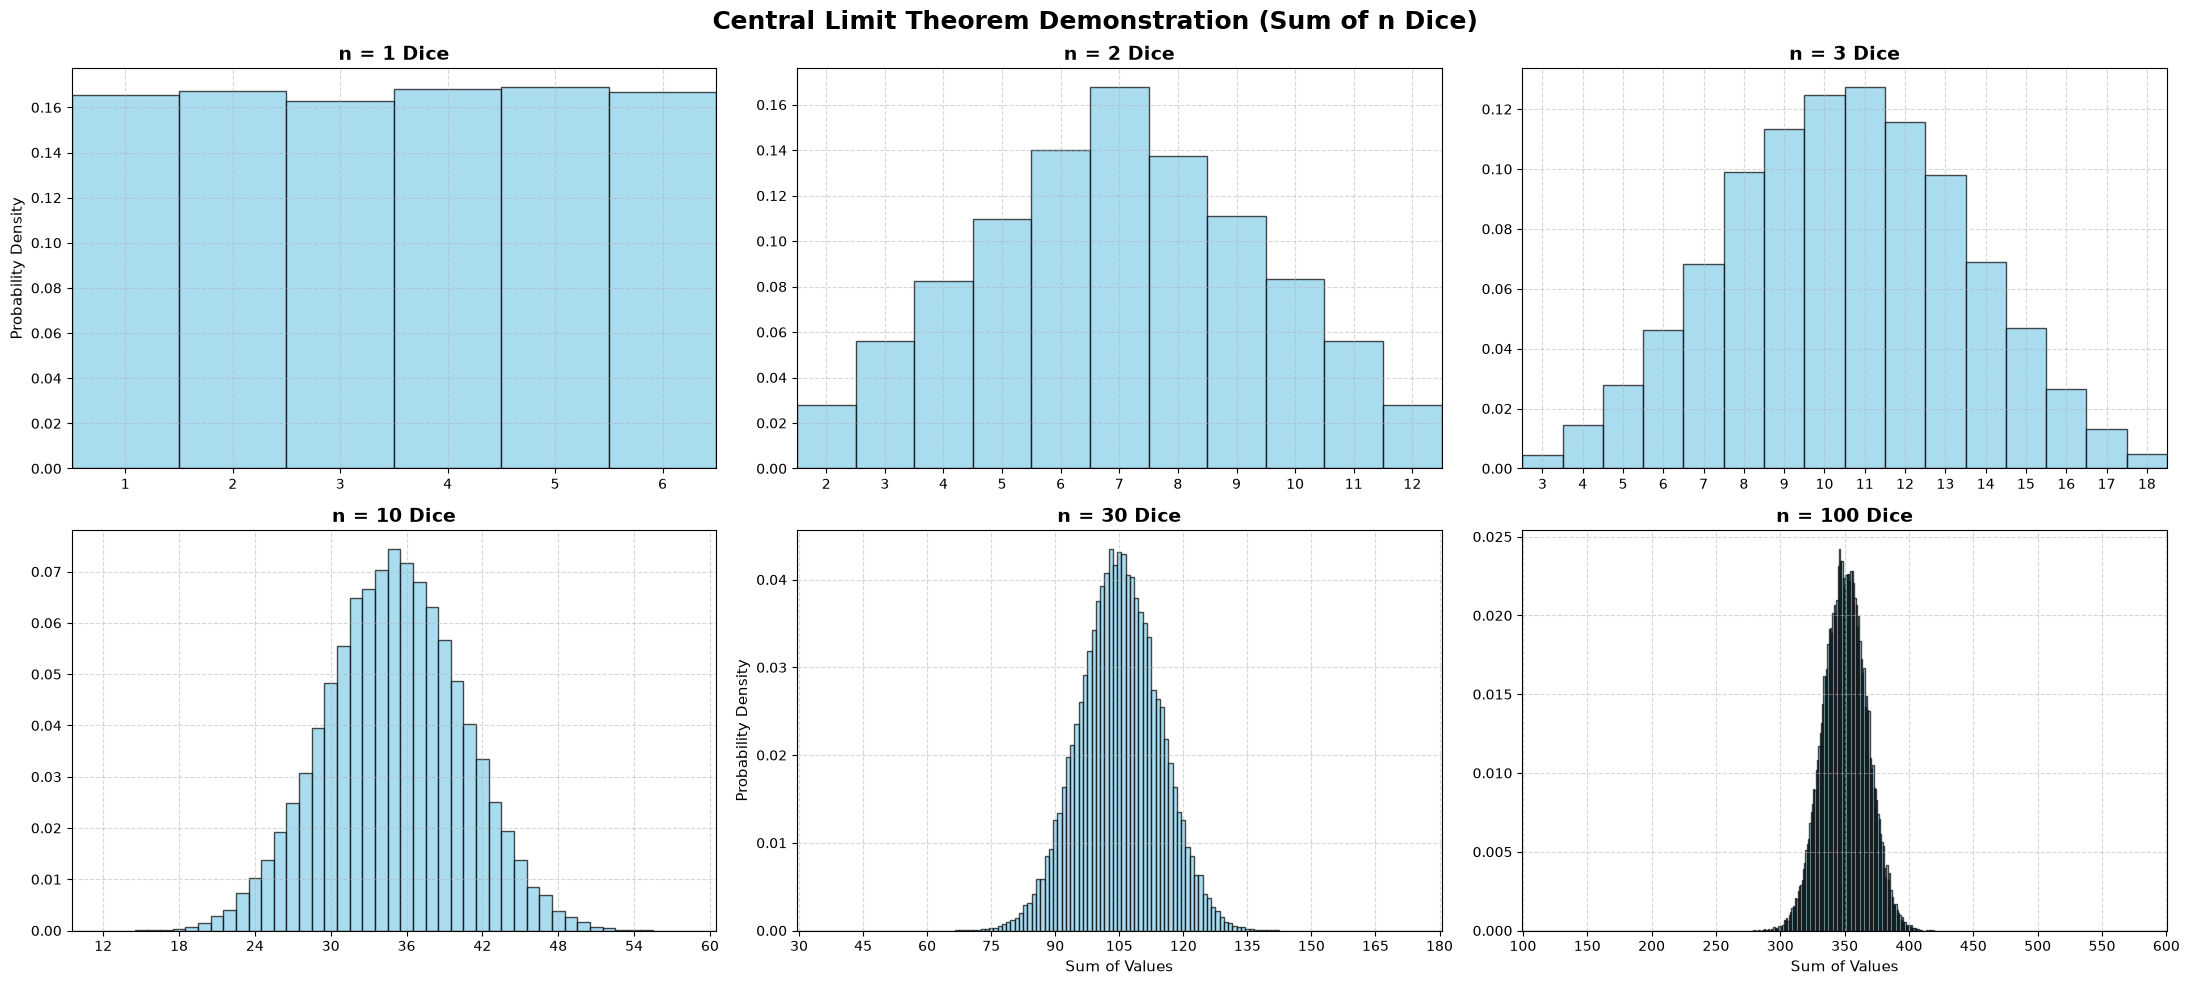

In [27]:
total_simulations = 50_000
n_values = [1, 2, 3, 10, 30, 100]

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
fig.suptitle('Central Limit Theorem Demonstration (Sum of n Dice)', fontsize=18, fontweight='bold', y=0.98)
axes_flat = axes.flatten()

for i, n in enumerate(n_values):
    ax = axes_flat[i]
    rolls = np.random.randint(1, 7, size=(total_simulations, n))
    sums = np.sum(rolls, axis=1)
    
    min_sum = n
    max_sum = 6 * n
    bins = np.arange(min_sum, max_sum + 2) - 0.5
    
    ax.hist(sums, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'n = {n} Dice', fontsize=14, fontweight='bold')
    ax.grid(axis='both', linestyle='--', alpha=0.5)
    ax.set_xlim(min_sum - 0.5, max_sum + 0.5)
    
    if n <= 3:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    elif n <= 15:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
    else:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
        
    if i >= 4:
        ax.set_xlabel('Sum of Values', fontsize=11)
    if i % 4 == 0:
        ax.set_ylabel('Probability Density', fontsize=11)

plt.tight_layout()
plt.show()

## 3. Dynamic Application: From Probability to Sample Size Requirement
A powerful aspect of the CLT is the ability to bridge active experimental probability back into future sample size planning.

### Scenario:
Suppose we are flipping a biased coin where the true probability of heads is $p = 0.4$.
* Theoretical mean ($\mu$) = $0.4$
* Theoretical standard deviation ($\sigma$) = $\sqrt{0.4 \times 0.6} \approx 0.4899$

We want to find the probability that our sample proportion of heads deviates from the true probability by no more than a margin of error of $3\%$ (i.e., the proportion stays between $0.37$ and $0.43$). For $n=1000$ trials, this corresponds to the total number of heads staying between $370$ and $430$.

In [28]:
n_fixed = 1000
p_true = 0.4
single_mean = 0.4
single_std = math.sqrt(p_true * (1 - p_true))
margin_of_error = 0.03
lower_b = int(n_fixed * (single_mean - margin_of_error))
upper_b = int(n_fixed * (single_mean + margin_of_error))
calculated_prob = clt_interval_probability(n_fixed, single_mean, single_std, lower_bound=lower_b, upper_bound=upper_b)
print(f"[CLT] Probability that the sum falls between {lower_b} and {upper_b} for n={n_fixed}: {calculated_prob:.4f}")

[CLT] Probability that the sum falls between 370 and 430 for n=1000: 0.9472


### Visualizing the CLT Interval
Let's visualize the exact standard normal curve area that our `clt_interval_probability` function evaluated by mapping the bounds to their standardized $Z$-scores.

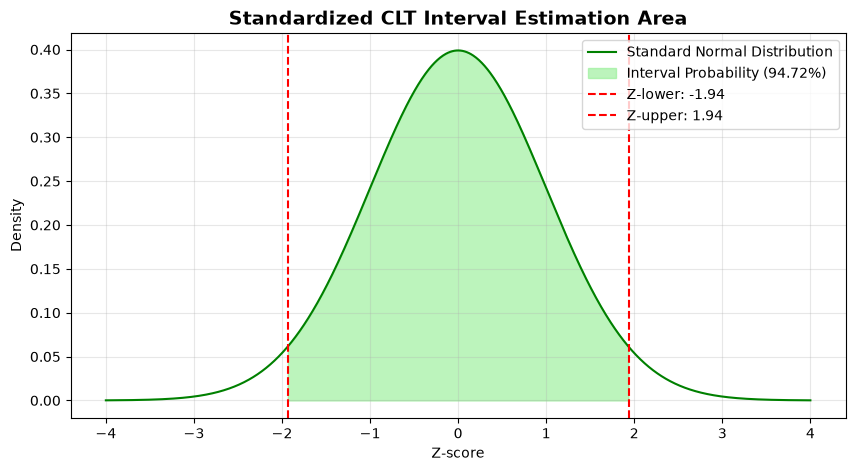

In [29]:
z_lower = (lower_b - n_fixed * single_mean) / (single_std * math.sqrt(n_fixed))
z_upper = (upper_b - n_fixed * single_mean) / (single_std * math.sqrt(n_fixed))

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'g-', label='Standard Normal Distribution')
plt.fill_between(x, y, where=(x >= z_lower) & (x <= z_upper), color='lightgreen', alpha=0.6, label=f'Interval Probability ({calculated_prob:.2%})')
plt.axvline(z_lower, color='red', linestyle='--', label=f'Z-lower: {z_lower:.2f}')
plt.axvline(z_upper, color='red', linestyle='--', label=f'Z-upper: {z_upper:.2f}')
plt.title('Standardized CLT Interval Estimation Area', fontsize=14, fontweight='bold')
plt.xlabel('Z-score')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Reversing the Goal
If we now demand this exact confidence level (`calculated_prob`) and want to ensure our sample proportion stays within a $3\%$ margin of error (`margin_of_error = 0.03`), how large must our sample size be?

In [30]:
required_n = calculate_sample_size(p=p_true, margin_of_error=margin_of_error, confidence_level=calculated_prob)
print(f"[Sample Size Required] Minimum n needed: {required_n}")

[Sample Size Required] Minimum n needed: 1001


## 4. Practical Application & Visualization: Poisson Distribution
The Poisson distribution models rare events occurring at a constant average rate ($\lambda = n \times p$).

### Scenario:
A company sends $n = 2000$ customer service emails. The probability of an email causing a bug report is $p = 0.0015$. We evaluate the probability of receiving exactly 3 reports, and cumulative metrics for 0 to 3 reports.

In [31]:
n_emails = 2000
p_bug = 0.0015
lam = n_emails * p_bug  # Expected average rate (lambda = 3)

exact_3_prob = poisson_pmf(n_emails, p_bug, k=3)
print(f"Probability of receiving EXACTLY 3 bug reports: {exact_3_prob:.4f}")

target_scenarios = [0, 1, 2, 3]
cumulative_prob, trial_variance = poisson_extended(n_emails, p_bug, target_scenarios)
print(f"Probability of receiving AT MOST 3 bug reports: {cumulative_prob:.4f}")

Probability of receiving EXACTLY 3 bug reports: 0.2240
Probability of receiving AT MOST 3 bug reports: 0.6472


### Visualizing the Poisson Probability Mass Function (PMF)
To better understand the scenario, let's plot the probability mass function for various counts of bug occurrences. This highlights where the bulk of the risk lies.

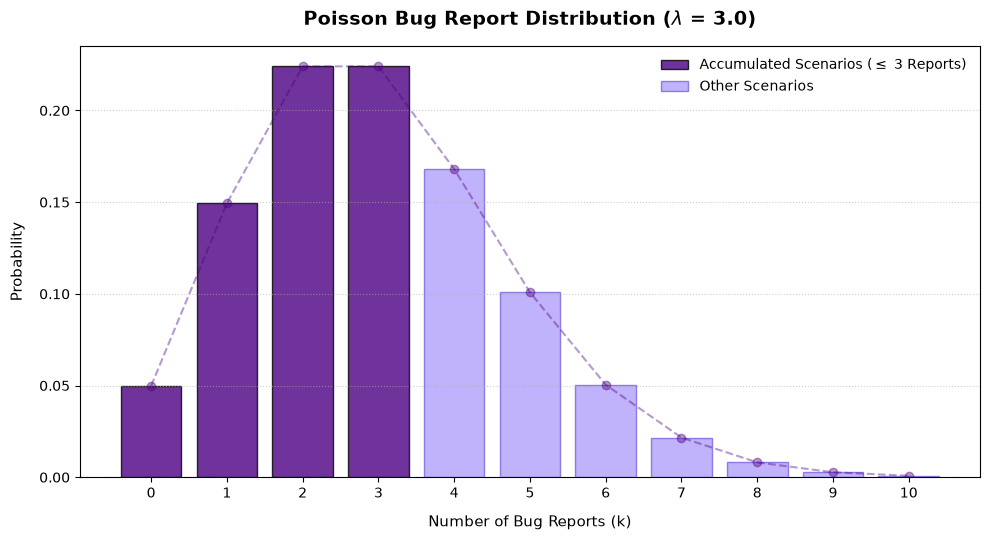

In [35]:
k_values = np.arange(0, 11)
pmf_probabilities = [poisson_pmf(n_emails, p_bug, int(k)) for k in k_values]


plt.figure(figsize=(10, 5.5))

bars = plt.bar(k_values, pmf_probabilities, color='#b19ffb', edgecolor='#7a62df', alpha=0.8)

for idx in target_scenarios:
    bars[idx].set_color('#4b0082')
    bars[idx].set_edgecolor('black')

bars[4].set_label('Other Scenarios')
bars[3].set_label(r'Accumulated Scenarios ($\leq$ 3 Reports)')

plt.plot(k_values, pmf_probabilities, color='#4b0082', linestyle='--', marker='o', alpha=0.4)

plt.title(rf'Poisson Bug Report Distribution ($\lambda$ = {lam:.1f})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Bug Reports (k)', fontsize=11, labelpad=10)
plt.ylabel('Probability', fontsize=11, labelpad=10)
plt.xticks(k_values)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()


### **Visualization Summary**

* **Target Range Interpretation:** The dark indigo bars highlight our `target_scenarios` ($k \leq 3$). Visually summing these specific outcomes directly yields the cumulative probability of receiving **at most 3 bug reports**.
* **The Trend Line:** The dashed gray line traces the continuous shape of the discrete Poisson PMF, highlighting its right-skewed nature.
* **The Bimodal Peak:** The identical maximum height of bars $k = 2$ and $k = 3$ ($\approx 22.40\%$) is mathematically expected. Whenever $\lambda$ is an integer, the distribution peaks equally at $k = \lambda - 1$ and $k = \lambda$.


## 5. Key Takeaways

* **The Power of CLT:** The Central Limit Theorem allows us to make normal-distribution-based assumptions about the **sum** or **mean** of data samples, even if the underlying source data is heavily skewed or discrete (as demonstrated by the dice simulation).
* **Strategic Sample Planning:** By using `clt_interval_probability` alongside `calculate_sample_size`, engineers and researchers can predict experimental risks and reverse-engineer the precise data volume required to achieve specific business or scientific confidence thresholds.
* **Poisson Efficiency:** For modeling rare, independent events over large trial sets ($n \to \infty$, $p \to 0$), the Poisson distribution provides an computationally efficient shortcut to estimate risk profiles and manage infrastructure capacities (e.g., bug tracking, server loads) without handling massive combinatorial calculations.
